In [1]:
root = r"/zhome/2f/7/202918/phc_nzi"
src = r"/zhome/2f/7/202918/phc_nzi/src"
import sys
sys.path.append(root)
sys.path.append(src)

## Define the materials
from src.photonic_crystal_maker import (Material, Geometry, PhotonicCrystal, 
                                        ScriptParam, ScriptParamVector3, BaseDielectricDistribution,
                                        HexagonalLattice)
import meep as mp
from src.mpb_configurator import *
from src.mpi_differential_evolution import MPIdeOptimizator
from src.simulation_handler import LSFJobConfiguration, MPBDataOptions, Simulation
from src.optimization_data_analyzer import OptimizationDataAnalyzer
from src.simulation_viewer import SimulationViewer
from src.sweeper import ParamSweeper

import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors

T = 4
n_InP = 3.075*(1+2.7e-5*T)
print(n_InP)
eps = round(n_InP**2,2)
print("Epsilon of InP: ", eps)
InP = Material(epsilon = eps)
air = Material(epsilon = 1)
## Simulation Name: 
name = "C4v_diatomic_T4"

## Define the geometry
radius1 = ScriptParam("r1", 0.3)
radius2 = ScriptParam("r2", 0.2)
height_supercell = 3
height_slab = ScriptParam("h", 0.4)
slab_block_size = ScriptParamVector3(1e20, 1e20, "h", z_def = 0.4)

## Define the lattice

lattice_2D = SquareLattice()
lattice_slab = SquareLattice(supercell_height= 4)

k_points = lattice_2D.get_high_symmetry_k_points(centered_in_gamma=False)
print(k_points)


center = mp.Vector3(0,0,0)


geom_2D = BaseDielectricDistribution().make_C4v_diatomic_B()
geom_slab = BaseDielectricDistribution(height_slab=0.5).make_C4v_diatomic_B()


photonic_crystal_2D = PhotonicCrystal(lattice=lattice_2D, atoms=geom_2D)
photonic_crystal_slab = PhotonicCrystal(lattice=lattice_slab, atoms=geom_slab)

## Define the simulation
configuration_options = dict(
    resolution = 32, 
    num_bands=12,
    k_points=k_points["k_points_values"],
    k_points_interpolation_factor = 10,
    extra_runner_command = "(output-at-kpoint (vector3 0 0 0) fix-hfield-phase output-hfield)",
)

configuration_options_optimization = dict(
    resolution = 64, 
    num_bands=10,
    k_points = [mp.Vector3(0,0,0)],
    
)

configuration_options_sweep = dict( 
    resolution = 64,
    num_bands=10,
    k_points=[mp.Vector3(0,0,0)],
)


mpb_configuration_2D = MPBSchemeConfigurator(photonic_crystal_2D, ["te", "tm"], **configuration_options)
mpb_configuration_slab = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven"], **configuration_options)
mpb_configuration_2D_opt = MPBSchemeConfigurator(photonic_crystal_2D, ["te"], **configuration_options_optimization)
mpb_configuration_slab_opt = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven"], **configuration_options_optimization)
mpb_configuration_slab_sweep = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven"], **configuration_options_sweep)

script_2D = mpb_configuration_2D.get_scheme_config(join_newline=True)
script_slab = mpb_configuration_slab.get_scheme_config(join_newline=True)
script_2D_opt = mpb_configuration_2D_opt.get_scheme_config(join_newline=True)
script_slab_opt = mpb_configuration_slab_opt.get_scheme_config(join_newline=True)
script_slab_sweep = mpb_configuration_slab_sweep.get_scheme_config(join_newline=True)




name_2D = name  + "_2D"
name_slab = name + "_slab"
name_2D_opt = name + "_2D_opt"
name_slab_opt = name + "_slab_opt"
name_slab_sweep = name + "_slab_sweep"

data_rooth = "/work3/s232699/phc_nzi/data/"

simulation_2D = Simulation(
    simulation_name=name_2D,
    script = script_2D,
    directory= os.path.join(data_rooth, name_2D)
    )

simulation_2D_opt = Simulation(
    simulation_name=name_2D_opt,
    script = script_2D_opt,
    directory= os.path.join(data_rooth, name_2D_opt)
    )

simulation_slab = Simulation(
    simulation_name=name_slab,
    script = script_slab,
    directory= os.path.join(data_rooth, name_slab)
    )


simulation_slab_opt = Simulation(
    simulation_name=name_slab_opt,
    script = script_slab_opt,
    directory= os.path.join(data_rooth, name_slab_opt)  
    )

simulation_slab_sweep = Simulation(
    simulation_name=name_slab_sweep,
    script = script_slab_sweep,
    directory= os.path.join(data_rooth, name_slab_sweep)  
    )



numproc= 32
pop = numproc // 2
lsf_config = LSFJobConfiguration(num_processors=numproc, span_option="block", span_value=8, queue="fotonano")


3.0753321000000002
Epsilon of InP:  9.46
{'k_points_values': [Vector3<0.0, 0.0, 0.0>, Vector3<0.5, 0.0, 0.0>, Vector3<0.5, 0.5, 0.0>, Vector3<0.0, 0.0, 0.0>], 'k_points_labels': ['$\\Gamma$', 'X', 'M', '$\\Gamma$']}
COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 0.5)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 0.5)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 0.5)', '(define-param r1 0.1)', '(define-param r2 0.2)']


2D simulation done


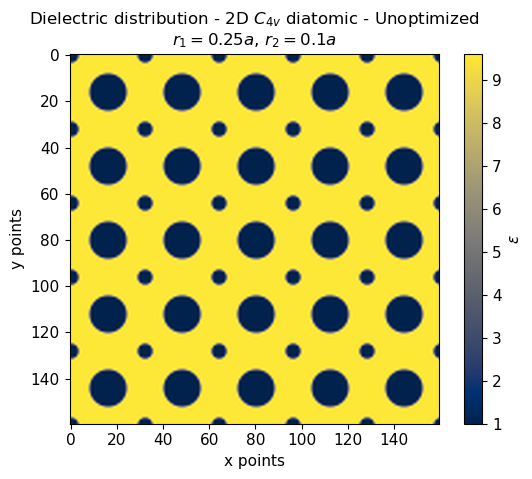

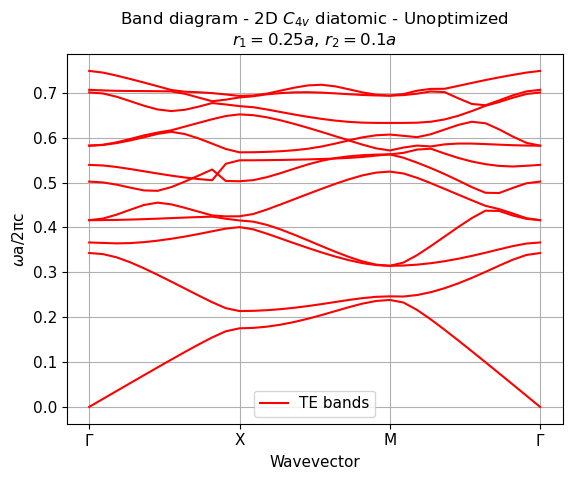

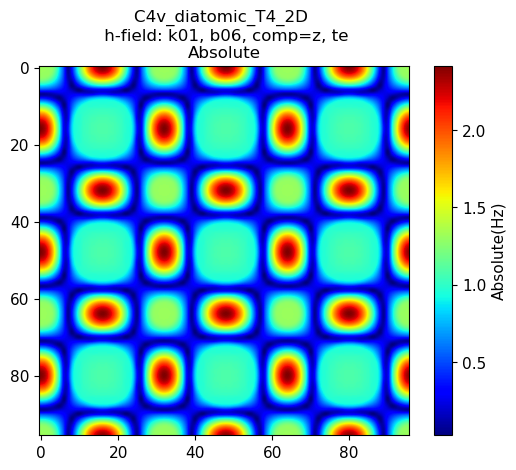

In [2]:
r1 = 0.25
r2 = 0.1
#simulation_2D.run_hpc(mpb_command_line_params=dict(r1 = 0.2400, r2 = 0.2334), mpi = True)4
simulation_2D.run_hpc(mpb_command_line_params=dict(r1 = r1, r2 = r2), mpi = True)
print("2D simulation done")
viewer_2D = SimulationViewer(simulation_2D) 
opt = MPBDataOptions(rectify=True, periods= 5)
viewer_2D.figure()
viewer_2D.plot_epsilon_2d(conversion_options=opt)
plt.xlabel("x points")
plt.ylabel("y points")
data_line = f"$r_1={r1}a$, $r_2={r2}a$"
plt.title("Dielectric distribution - 2D $C_{4v}$ diatomic - Unoptimized\n" + data_line)
viewer_2D.show()

viewer_2D.plot_band_diagram("te", k_points_path=k_points, color = "red")
#viewer_2D.plot_band_diagram("tm", k_points_path=k_points, color = "blue")
plt.ylabel("$\omega$a/2πc")
plt.title("Band diagram - 2D $C_{4v}$ diatomic - Unoptimized\n" + data_line)
viewer_2D.show()

viewer_2D.plot_field_2d(1, 6, "h", "z", "te", False, np.abs) 


<Figure size 640x480 with 0 Axes>

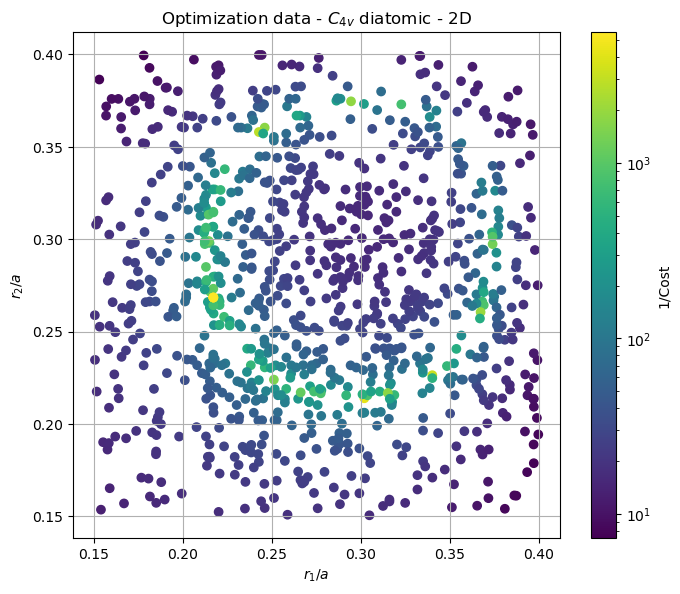

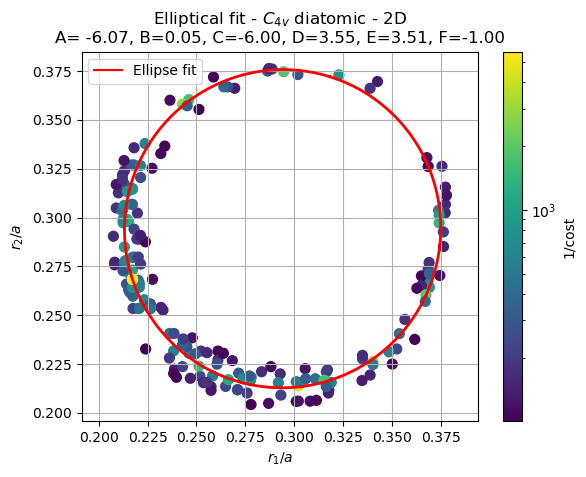

In [3]:
optimizer = MPIdeOptimizator(
        simulation_name=simulation_2D_opt.simulation_name,
        scheme_script=simulation_2D_opt.script, 
        maxiter=30,
        param_names=["r1", "r2"],
        param_bounds=[(0.15, 0.4), (0.15, 0.4)],
        polarization="te",
        de_options={"strategy": "rand1bin", "popsize": pop},
        bands=[4,5,6],
        directory=os.path.join(data_rooth, simulation_2D_opt.simulation_name),
    )
# optimizer.erease_data_file()
# optimizer.submit_lsf_job(lsf_config)

analyzer = OptimizationDataAnalyzer(optimizer.data_file)
plt.figure()
analyzer.plot_raw_data(plot_inverse_cost=True, points_only=True, use_logscale=True)
plt.grid() 
plt.xlabel("$r_1/a$")
plt.ylabel("$r_2/a$") 
plt.title("Optimization data - $C_{4v}$ diatomic - 2D")   
plt.show()

df = analyzer.get_points_above_treshold(100)


norm = colors.LogNorm(vmin=(1/df["cost"]).min(), vmax=(1/df["cost"]).max())
plt.scatter(df["r1"], df["r2"], c=1/df["cost"], cmap="viridis", norm=norm, s=50)
plt.colorbar(label="1/cost")
a = analyzer.fit_ellipse(df["r1"], df["r2"], 1/df["cost"])
analyzer.plot_ellipse_from_conic(*a)
plt.xlabel("$r_1/a$")
plt.ylabel("$r_2/a$")

fit_text = f"A= {a[0]:.2f}, B={a[1]:.2f}, C={a[2]:.2f}, D={a[3]:.2f}, E={a[4]:.2f}, F={a[5]:.2f}"
plt.title("Elliptical fit - $C_{4v}$ diatomic - 2D\n" + fit_text)
plt.plot(np.nan, np.nan,"r-", label="Ellipse fit")
plt.legend()
plt.grid()
plt.show()




r2:  0.2334979553581385
2D simulation done


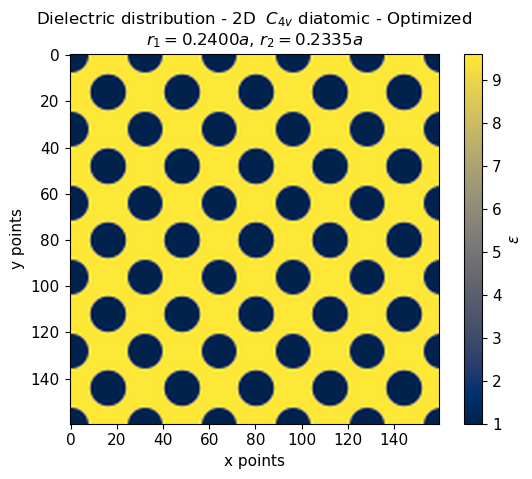

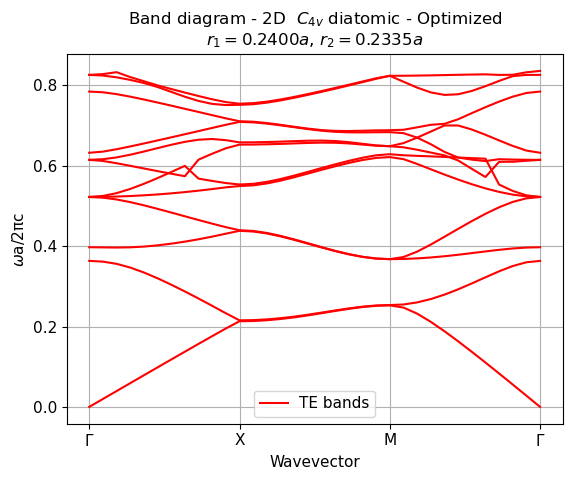

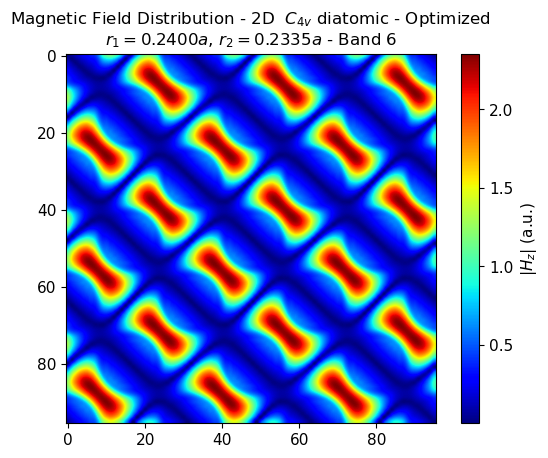

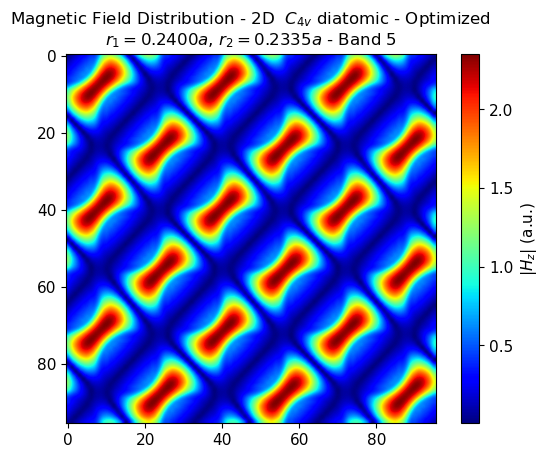

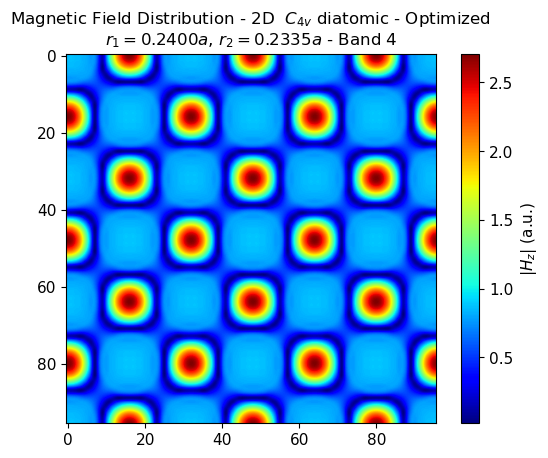

In [5]:
r1 = 0.24
r2 = analyzer.compute_param2_from_param1_on_ellipse(r1, a, "lower")
print("r2: ", r2)

#simulation_2D.run_hpc(mpb_command_line_params=dict(r1 = 0.2400, r2 = 0.2334), mpi = True)
simulation_2D.run_hpc(mpb_command_line_params=dict(r1 = r1, r2 = r2), mpi = True)
print("2D simulation done")
viewer_2D = SimulationViewer(simulation_2D) 
opt = MPBDataOptions(rectify=True, periods= 5)
viewer_2D.figure()
viewer_2D.plot_epsilon_2d(conversion_options=opt)
plt.xlabel("x points")
plt.ylabel("y points")
data_line = f"$r_1={r1:.4f}a$, $r_2={r2:.4f}a$"
plt.title("Dielectric distribution - 2D  $C_{4v}$ diatomic - Optimized\n" + data_line)
viewer_2D.show()

viewer_2D.plot_band_diagram("te", k_points_path=k_points, color = "red")
#viewer_2D.plot_band_diagram("tm", k_points_path=k_points, color = "blue")
plt.ylabel("$\omega$a/2πc")
plt.title("Band diagram - 2D  $C_{4v}$ diatomic - Optimized\n" + data_line)
viewer_2D.show()

plt.figure()
c= viewer_2D.plot_field_2d(1, 6, "h", "z", "te", False, np.abs)
print(c)
plt.title("Magnetic Field Distribution - 2D  $C_{4v}$ diatomic - Optimized \n" + data_line + " - Band 6")
c.set_label("$|H_{z}|$ (a.u.)")
plt.show()

plt.figure() 
c=viewer_2D.plot_field_2d(1, 5, "h", "z", "te", False, np.abs)
plt.title("Magnetic Field Distribution - 2D  $C_{4v}$ diatomic - Optimized \n" + data_line + " - Band 5")
c.set_label("$|H_{z}|$ (a.u.)")
plt.show()


plt.figure()     
c=viewer_2D.plot_field_2d(1, 4, "h", "z", "te", False, np.abs)
plt.title("Magnetic Field Distribution - 2D  $C_{4v}$ diatomic - Optimized \n" + data_line + " - Band 4")
c.set_label("$|H_{z}|$ (a.u.)")
plt.show()

In [9]:
df = simulation_2D.load_frequency_data()
freq = simulation_2D.get_freq(df, 1, 5, "te")
print("Frequency: ", freq)
lam0 = 1550
a = freq*lam0
print(a)

Frequency:  0.522557
809.9633500000001


In [4]:
import concurrent.futures
import time

# Assume 'name' and 'script_slab' are defined elsewhere
pop = numproc // 2
h_array = [0.25, 0.3, 0.35, 0.4,0.45, 0.5, 0.55]

df_array= []
def run_optimization(h):
    opt_name = simulation_slab_opt.simulation_name + f"_p64_h_{h:0.3f}"
    optimizer = MPIdeOptimizator(
        simulation_name=opt_name,
        scheme_script=simulation_slab_opt.script,
        maxiter=15,
        param_names=["r1", "r2"],
        param_bounds=[(0.15, 0.35), (0.1, 0.35)],
        polarization="zeven",
        de_options={"strategy": "rand1bin", "popsize": pop},
        bands=[8, 9, 10],
        height_slab=h,
        directory=os.path.join(data_rooth, opt_name)
    )
    # Submit the LSF job.
    try:
        #optimizer.erease_data_file()
        pass
    except:
        pass
    #optimizer.submit_lsf_job(lsf_config)
    try:
        data_file = optimizer.data_file
        analyzer = OptimizationDataAnalyzer(data_file)
        plt.figure()
        analyzer.plot_raw_data(plot_inverse_cost=True, points_only=True, use_logscale=True)        
        plt.savefig(f"{optimizer.simulation.directory}/{opt_name}_raw_data_log_point.png")
        plt.close()
        plt.figure()
        analyzer.plot_optimization_points_freq_dirac(points_only=True)
        plt.savefig(f"{optimizer.simulation.directory}/{opt_name}_freq_center.png")
        plt.close()

        df = analyzer.get_points_above_treshold(1200)
        df["h"] = h
        df_array.append(df)

    except Exception as e:
        print(f"An error occurred while analyzing the data: {e}")

#Use ThreadPoolExecutor to run jobs concurrently with a small delay between job submissions.
with concurrent.futures.ThreadPoolExecutor() as executor:
    futures = []
    for h in h_array:
        futures.append(executor.submit(run_optimization, h))
        time.sleep(1)  # Add a small delay between submissions
    concurrent.futures.wait(futures)

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

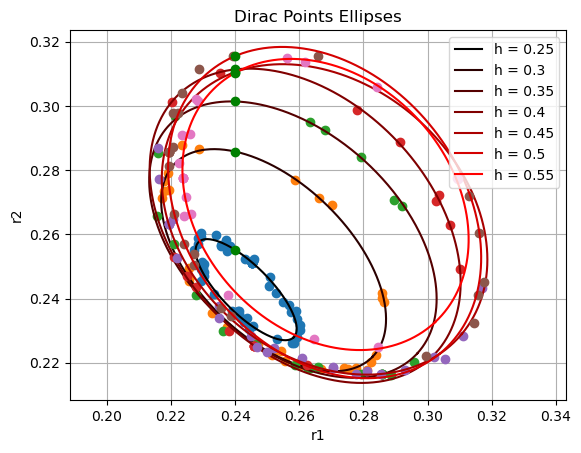

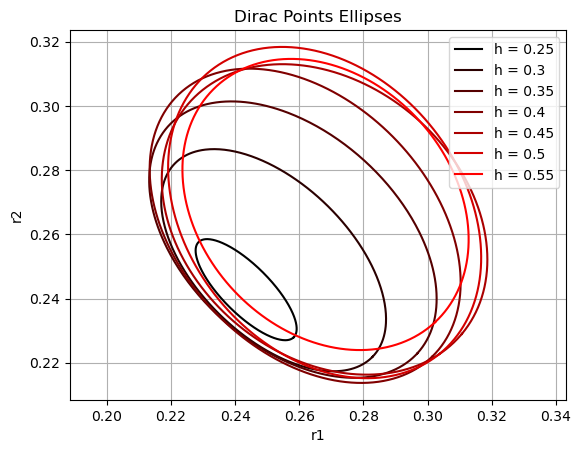

In [5]:
figure_ellipses = plt.figure()
figure_ellipses_no_point = plt.figure()
threshold = 1000
h_array = [0.25, 0.3, 0.35, 0.4,0.45, 0.5, 0.55]
plt.figure(figure_ellipses)
for h in h_array:
    try:
        h_norm = (h - min(h_array)) / (max(h_array) - min(h_array))
    except:
        h_norm = 1
    path_data_file = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_{h:0.3f}/{name_slab_opt}_p64_h_{h:0.3f}.de.data")
    analyzer = OptimizationDataAnalyzer(path_data_file)
    df = analyzer.get_points_above_treshold(threshold)
    a = analyzer.fit_ellipse(df["r1"], df["r2"], 1/df["cost"]) 
    plt.plot(df["r1"], df["r2"], "o")
    analyzer.plot_ellipse_from_conic(*a, plot_kwds={"color": [h_norm , 0, 0], "label": f"h = {h}"})
    r1 = 0.24
    r2 = analyzer.compute_param2_from_param1_on_ellipse(r1, a)
    plt.plot(r1, r2, "go")
plt.title(f"Dirac Points Ellipses")
plt.legend()
plt.grid()
plt.xlabel("r1")
plt.ylabel("r2")
plt.show()


plt.figure(figure_ellipses_no_point)
for h in h_array:
    try: 
        h_norm = (h - min(h_array)) / (max(h_array) - min(h_array))
    except:
        h_norm = 1
    path_data_file  = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_{h:0.3f}/{name_slab_opt}_p64_h_{h:0.3f}.de.data")
    analyzer = OptimizationDataAnalyzer(path_data_file)
    df = analyzer.get_points_above_treshold(threshold)
    a = analyzer.fit_ellipse(df["r1"], df["r2"], 1/df["cost"]) 
    plt.figure(figure_ellipses_no_point)
    analyzer.plot_ellipse_from_conic(*a, plot_kwds={"color": [h_norm , 0, 0], "label": f"h = {h}"})

plt.title(f"Dirac Points Ellipses")
plt.legend()
plt.grid()
plt.xlabel("r1")
plt.ylabel("r2")
plt.show()




In [6]:
path_data_file = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_0.350/{name_slab_opt}_p64_h_0.350.de.data")
analyzer = OptimizationDataAnalyzer(path_data_file)
points = analyzer.get_points_above_treshold(1000)
#display(points)
print(analyzer.compute_param2_from_param1_on_ellipse(0.23,branch="lower", threshold=1000))

0.2394961689824523


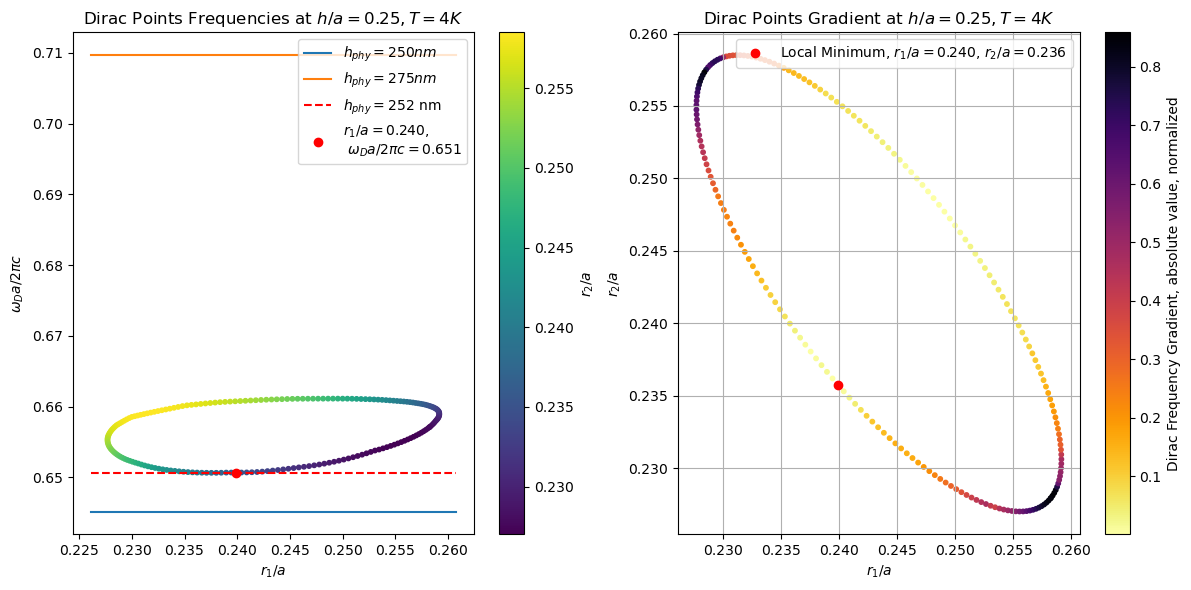

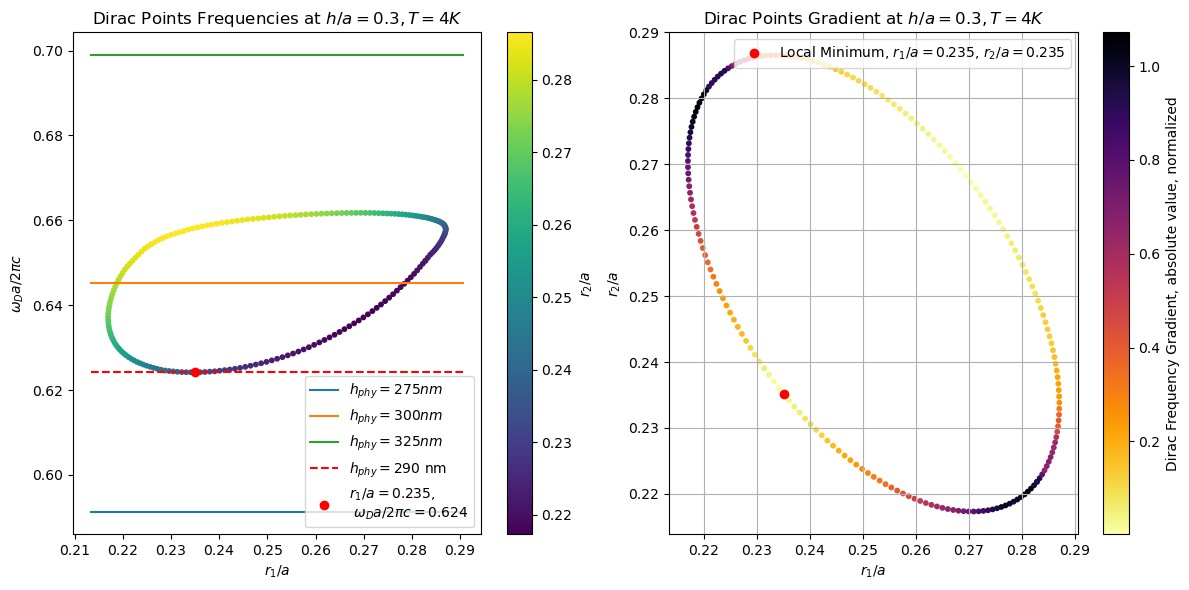

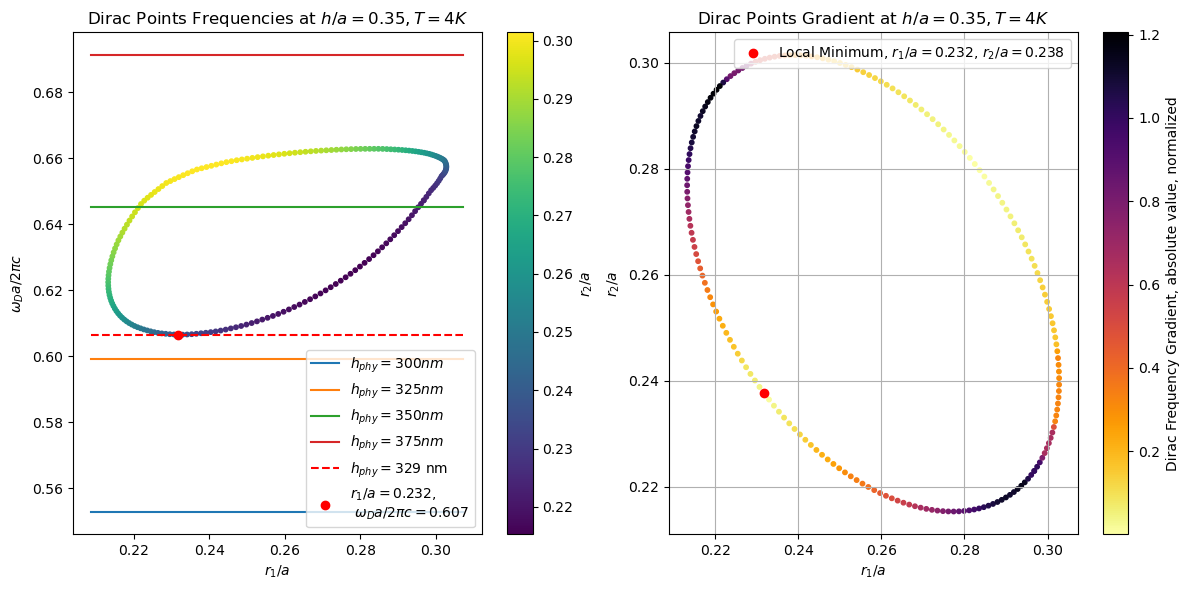

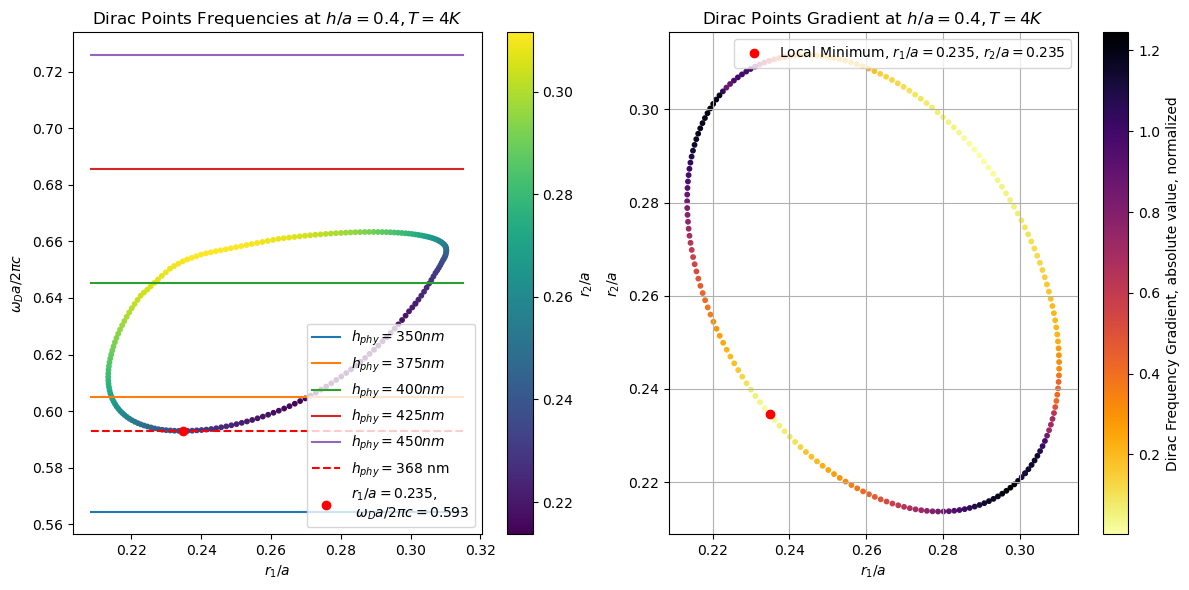

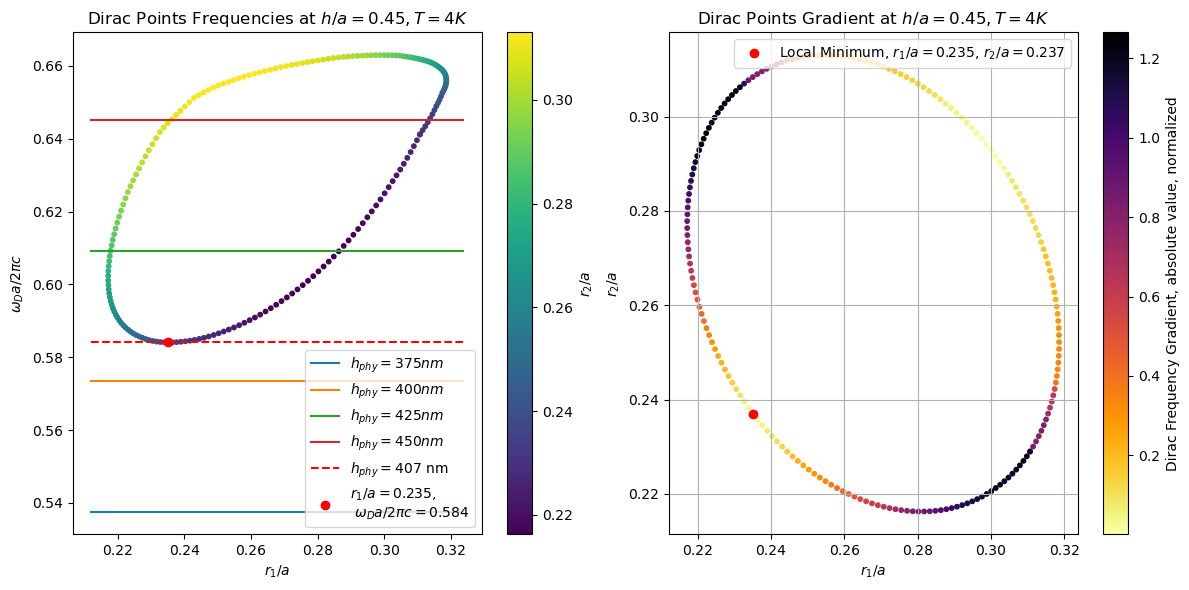

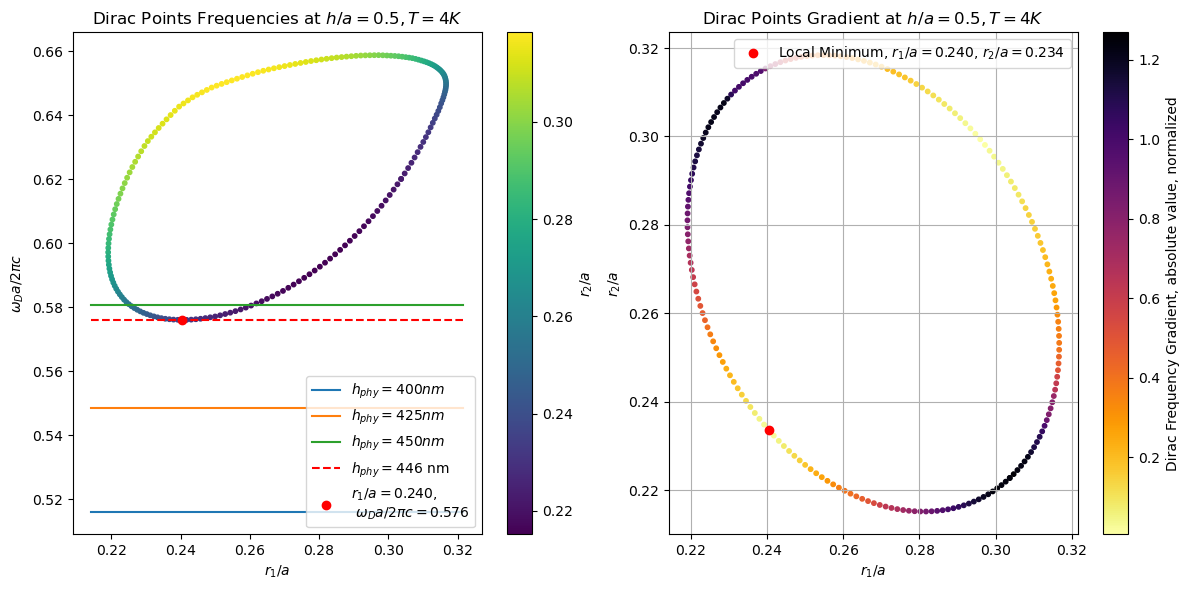

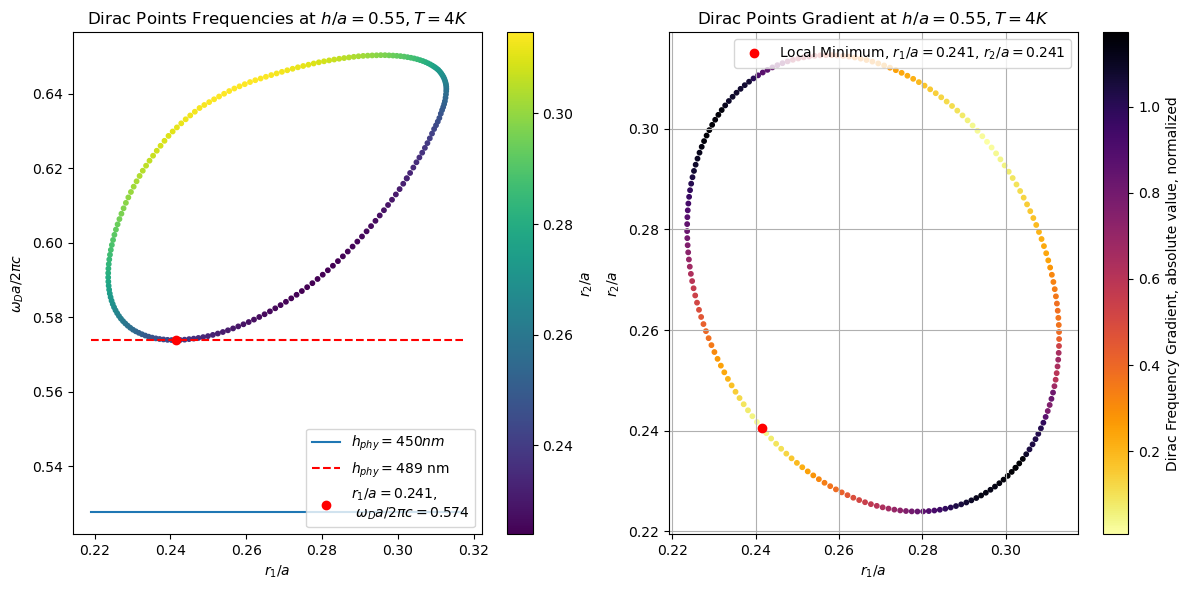

In [7]:
lambda0 = 1550
threshold = 1000

for i, h in enumerate(h_array):
    param2_delim = 0.25 if i >= 1 else 0.24
    param1_delim = 1    if i >= 1 else 0.24
    figure_freq_dirac, axes = plt.subplots(1, 2, figsize=(12, 6)) 
    plt.sca(axes[0])    
    path_data_opt = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_{h:0.3f}/{name_slab_opt}_p64_h_{h:0.3f}.de.data")
    analyzer = OptimizationDataAnalyzer(path_data_opt)
    x, y, f, aa = analyzer.compute_freq_dirac_along_ellipse(threshold=threshold)
    analyzer.plot_freq_dirac_along_ellipse(threshold=threshold)
    h_phy_array = [250, 275, 300, 325, 350,  375, 400, 425, 450]
    xlim = plt.xlim()
    ylim = plt.ylim()  
    for h_phy in h_phy_array:
        w_target = h_phy / lambda0/h
        if w_target < ylim[1]*1.1 and w_target > ylim[0]*0.9:   
            plt.plot(xlim, [w_target, w_target], label = f"$h_{{phy}} = {h_phy} nm$")
    plt.title(f"Dirac Points Frequencies at $h/a = {h}, T={T}K$")
    plt.legend()
    plt.grid()
    plt.xlabel("$r_1/a$")
    plt.ylabel("$\omega_{{D}}a/2\pi c$")
    colorbar = plt.colorbar() 
    colorbar.set_label("$r_2/a$")   



    plt.sca(axes[1])
    param1, param2, gradient, a= analyzer.compute_gradient_along_ellipse(threshold=threshold)
    mask = (param2 < param2_delim) & (param1 < param1_delim)
    param1_lower = param1[mask]
    param2_lower = param2[mask]
    gradient_lower = gradient[mask]
    idx_min = np.argmin(np.abs(gradient_lower))
    c = analyzer.plot_gradient_along_ellipse(threshold=threshold, abs = True)
    c.set_label("Dirac Frequency Gradient, absolute value, normalized")
    points = analyzer.get_points_above_treshold(threshold)
    # plt.scatter(points["r1"], points["r2"], c=1/points["cost"], cmap="viridis",
    #             norm=colors.LogNorm(vmin=(1/points["cost"]).min(), vmax=(1/points["cost"]).max()))
    plt.plot(param1_lower[idx_min], param2_lower[idx_min], "ro", label=f"Local Minimum, $r_1/a = {param1_lower[idx_min]:0.3f}$, $r_2/a = {param2_lower[idx_min]:0.3f}$")
    plt.title(f"Dirac Points Gradient at $h/a= {h}, T={T}K$")
    plt.legend(loc = "upper right")
    plt.xlabel("$r_1/a$")
    plt.ylabel("$r_2/a$")
    plt.grid()



    plt.sca(axes[0])
    f_lower = f[mask]   
    h_phy_target = f_lower[idx_min] * lambda0 * h
    plt.plot(xlim, [f_lower[idx_min], f_lower[idx_min]], "r--", label = f"$h_{{phy}} = {h_phy_target:0.0f}$ nm")
    plt.plot(param1_lower[idx_min], f_lower[idx_min], "ro", label = f"$r_1/a = {param1_lower[idx_min]:0.3f}$,\n $\omega_Da/2\pi c = {f_lower[idx_min]:0.3f}$")
    legend = plt.legend(loc = "upper right") if i == 0 else plt.legend(loc = "lower right")
    
 
    plt.show()





h/a: 0.25, lambda_0$: 1536.8811422070858, w_target: 0.6506684040406138, h_phy: 250


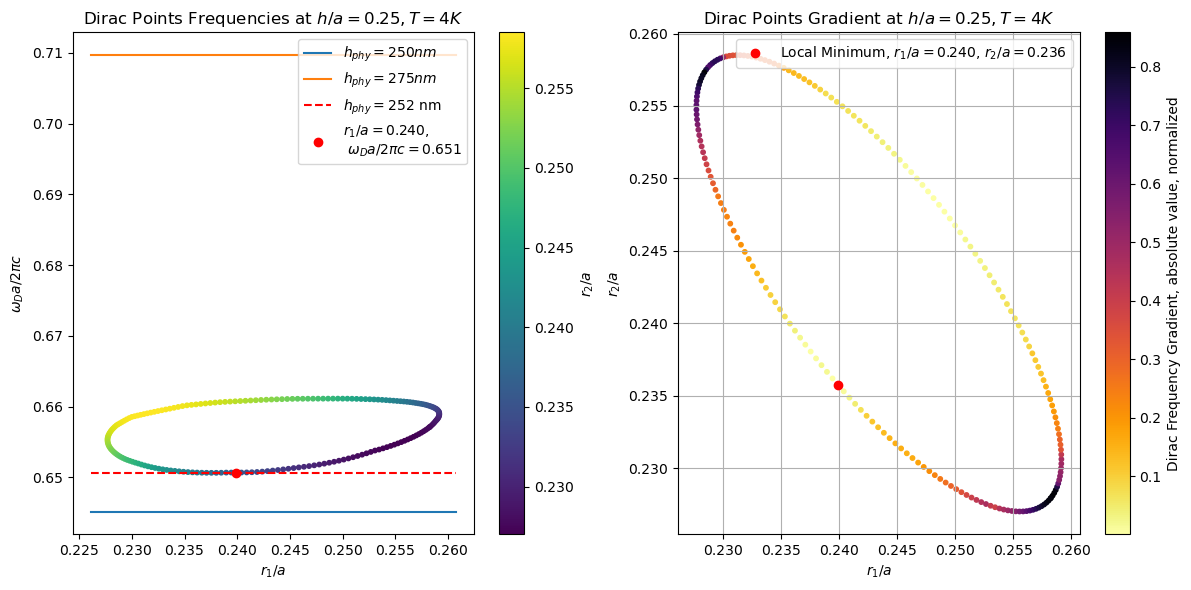

h/a: 0.3, lambda_0$: 1335.0573939057508, w_target: 0.6241928902362702, h_phy: 250


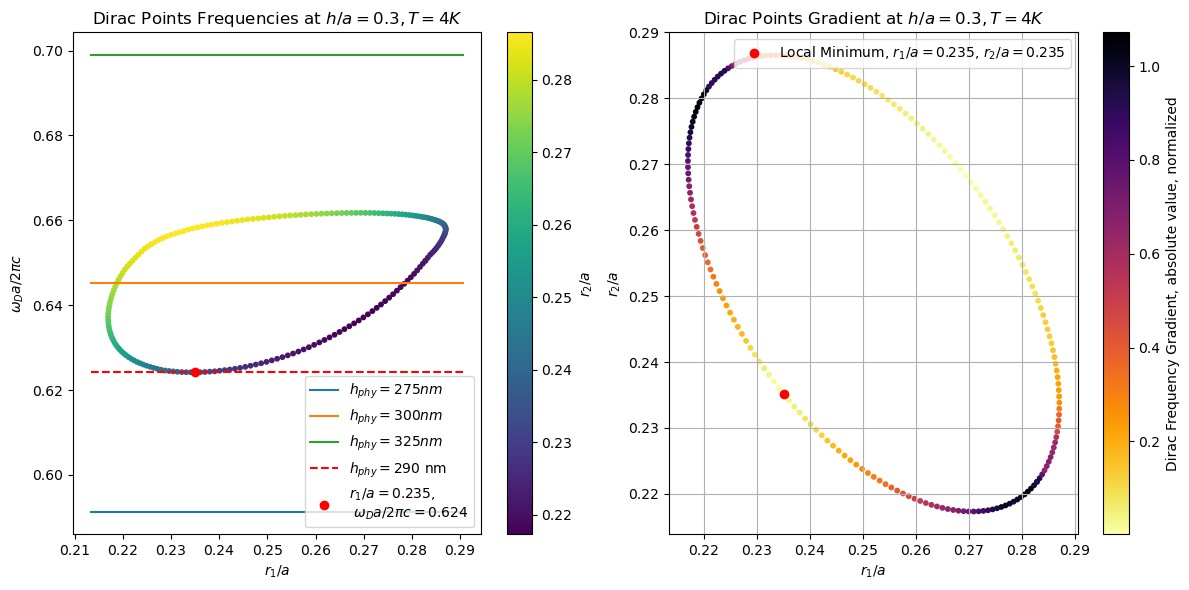

h/a: 0.35, lambda_0$: 1177.5667030183772, w_target: 0.606577710166935, h_phy: 250


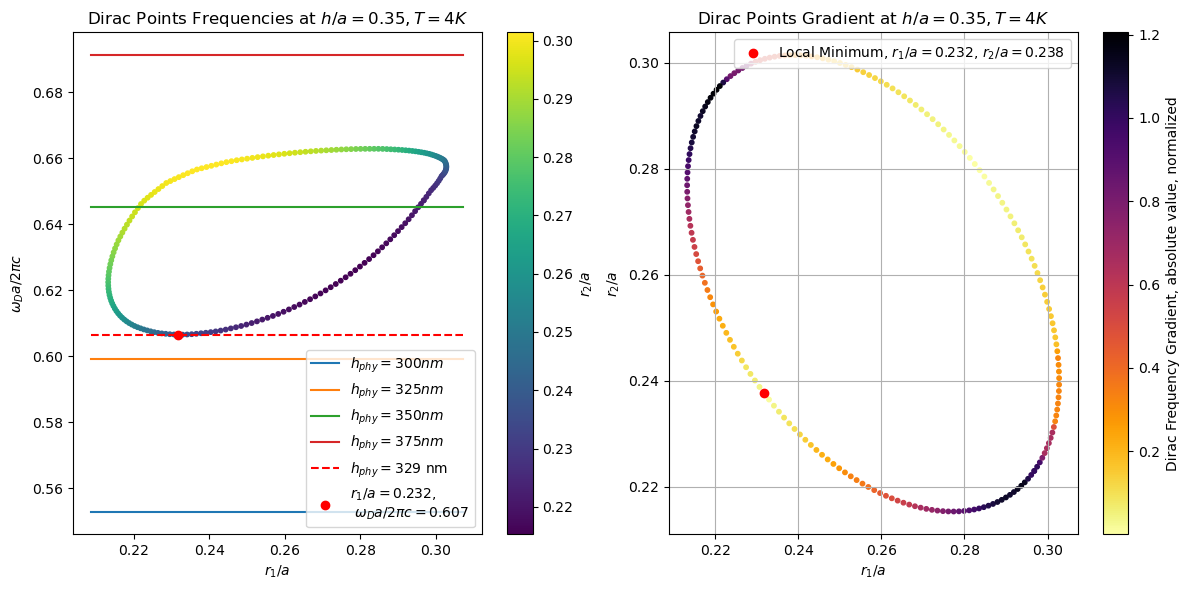

h/a: 0.4, lambda_0$: 1053.9874375420125, w_target: 0.5929861948426565, h_phy: 250


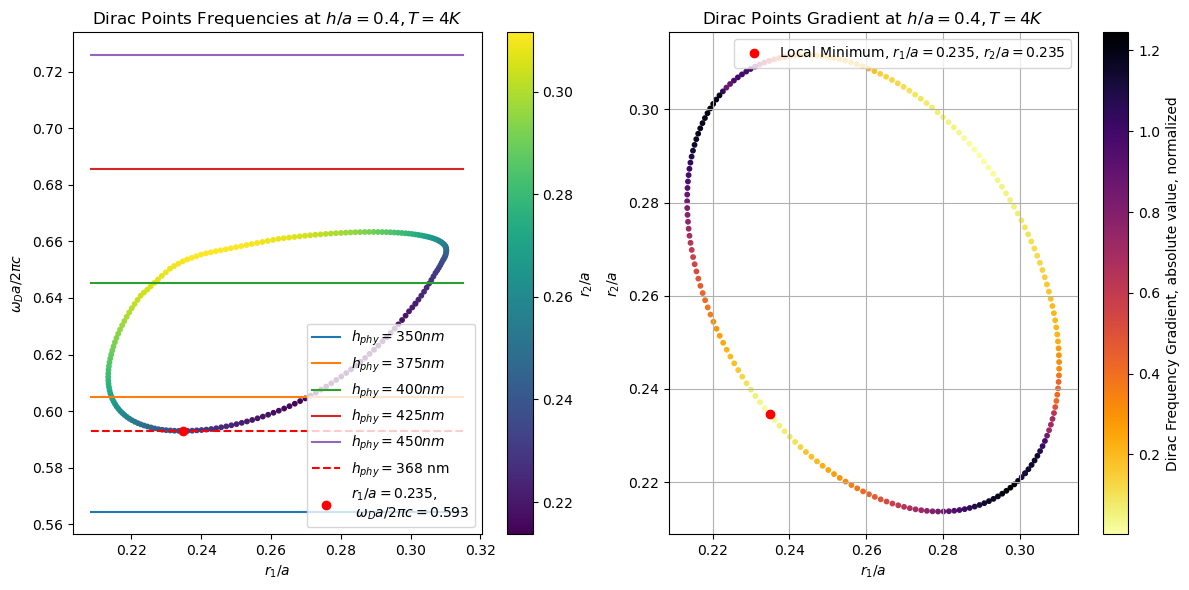

h/a: 0.45, lambda_0$: 951.1580704697186, w_target: 0.5840833114954287, h_phy: 250


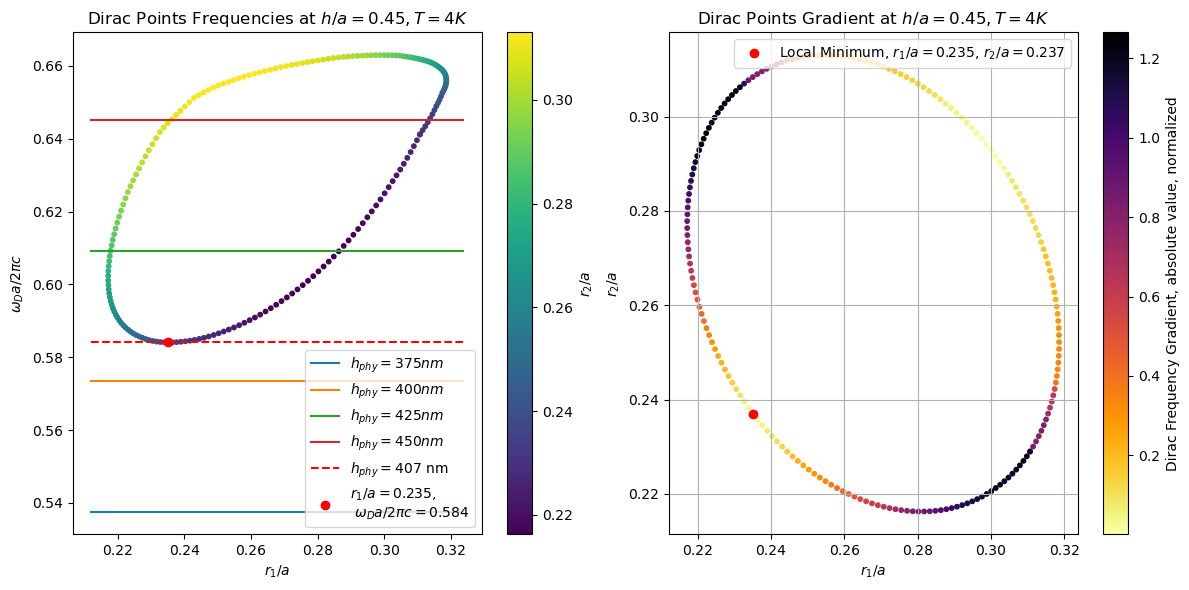

h/a: 0.5, lambda_0$: 868.0136236529246, w_target: 0.576027825341973, h_phy: 250


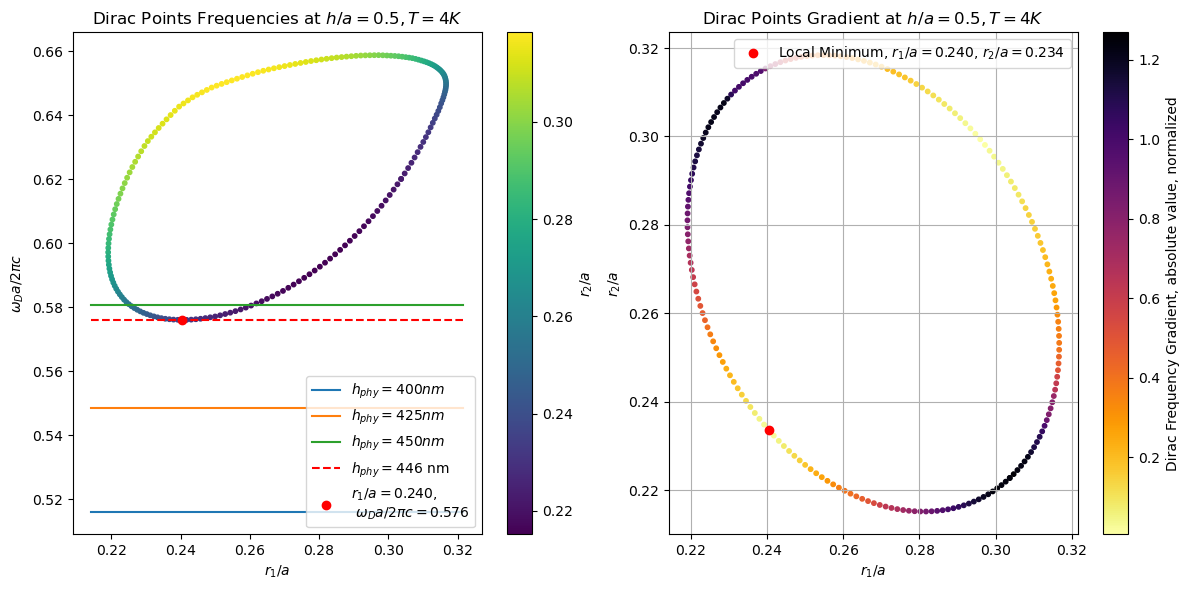

h/a: 0.55, lambda_0$: 792.0561503174293, w_target: 0.5738803421490863, h_phy: 250


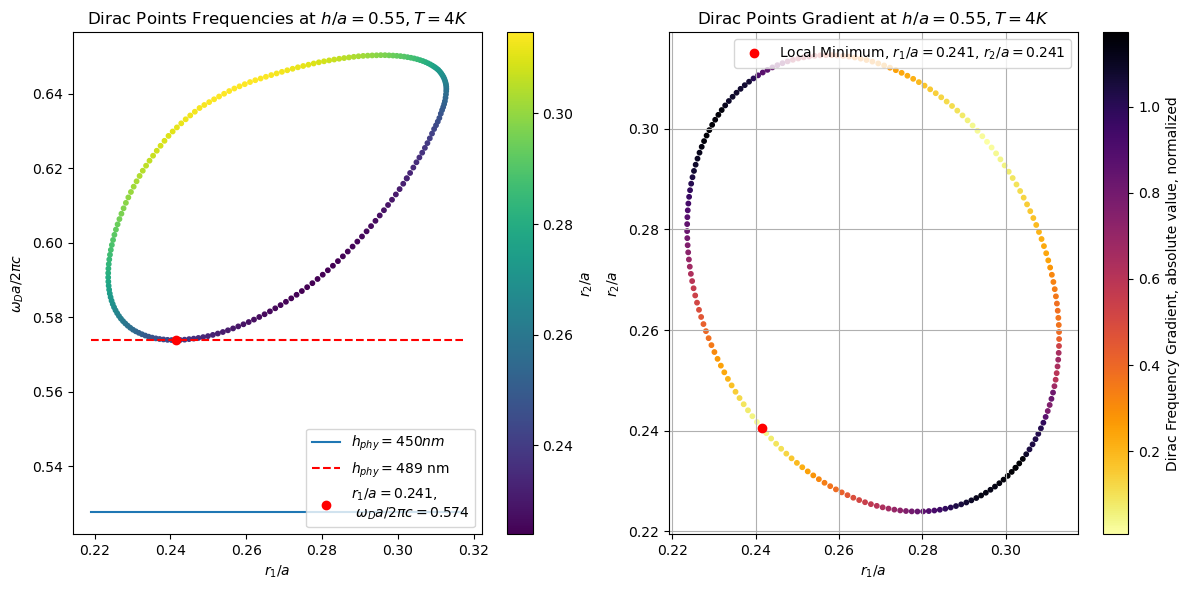

In [8]:
lambda0 = 1550
threshold = 1000

for i, h in enumerate(h_array):
    param2_delim = 0.25 if i >= 1 else 0.24
    param1_delim = 1    if i >= 1 else 0.24
    figure_freq_dirac, axes = plt.subplots(1, 2, figsize=(12, 6)) 
    plt.sca(axes[0])    
    path_data_opt = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_{h:0.3f}/{name_slab_opt}_p64_h_{h:0.3f}.de.data")
    analyzer = OptimizationDataAnalyzer(path_data_opt)
    x, y, f, aa = analyzer.compute_freq_dirac_along_ellipse(threshold=threshold)
    analyzer.plot_freq_dirac_along_ellipse(threshold=threshold)
    
    
    xlim = plt.xlim()
    ylim = plt.ylim()  
    for h_phy in h_phy_array:
        w_target = h_phy / lambda0/h
        if w_target < ylim[1]*1.1 and w_target > ylim[0]*0.9:   
            plt.plot(xlim, [w_target, w_target], label = f"$h_{{phy}} = {h_phy} nm$")
    plt.title(f"Dirac Points Frequencies at $h/a = {h}, T={T}K$")
    plt.legend()
    plt.grid()
    plt.xlabel("$r_1/a$")
    plt.ylabel("$\omega_{{D}}a/2\pi c$")
    colorbar = plt.colorbar() 
    colorbar.set_label("$r_2/a$")   



    plt.sca(axes[1])
    param1, param2, gradient, a= analyzer.compute_gradient_along_ellipse(threshold=threshold)
    mask = (param2 < param2_delim) & (param1 < param1_delim)
    param1_lower = param1[mask]
    param2_lower = param2[mask]
    gradient_lower = gradient[mask]
    idx_min = np.argmin(np.abs(gradient_lower))
    c = analyzer.plot_gradient_along_ellipse(threshold=threshold, abs = True)
    c.set_label("Dirac Frequency Gradient, absolute value, normalized")
    points = analyzer.get_points_above_treshold(threshold)
    # plt.scatter(points["r1"], points["r2"], c=1/points["cost"], cmap="viridis",
    #             norm=colors.LogNorm(vmin=(1/points["cost"]).min(), vmax=(1/points["cost"]).max()))
    plt.plot(param1_lower[idx_min], param2_lower[idx_min], "ro", label=f"Local Minimum, $r_1/a = {param1_lower[idx_min]:0.3f}$, $r_2/a = {param2_lower[idx_min]:0.3f}$")
    plt.title(f"Dirac Points Gradient at $h/a= {h}, T={T}K$")
    plt.legend(loc = "upper right")
    plt.xlabel("$r_1/a$")
    plt.ylabel("$r_2/a$")
    plt.grid()



    plt.sca(axes[0])
    f_lower = f[mask]   
    h_phy_target = f_lower[idx_min] * lambda0 * h
    plt.plot(xlim, [f_lower[idx_min], f_lower[idx_min]], "r--", label = f"$h_{{phy}} = {h_phy_target:0.0f}$ nm")
    plt.plot(param1_lower[idx_min], f_lower[idx_min], "ro", label = f"$r_1/a = {param1_lower[idx_min]:0.3f}$,\n $\omega_Da/2\pi c = {f_lower[idx_min]:0.3f}$")
    legend = plt.legend(loc = "upper right") if i == 0 else plt.legend(loc = "lower right")

    h_phy = 250
    lambdaX = h_phy / h/ f_lower[idx_min]
    print(f"h/a: {h}, lambda_0$: {lambdaX}, w_target: {f_lower[idx_min]}, h_phy: {h_phy}")
    
    
 
    plt.show()





In [ ]:
lambda0 = 1550
threshold = 1000

for i, h in enumerate(h_array):
    param2_delim = 0.25 if i >= 1 else 0.24
    param1_delim = 1    if i >= 1 else 0.24
    figure_freq_dirac, axes = plt.subplots(1, 2, figsize=(12, 6)) 
    plt.sca(axes[0])    
    path_data_opt = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_{h:0.3f}/{name_slab_opt}_p64_h_{h:0.3f}.de.data")
    analyzer = OptimizationDataAnalyzer(path_data_opt)
    x, y, f, aa = analyzer.compute_freq_dirac_along_ellipse(threshold=threshold)
    analyzer.plot_freq_dirac_along_ellipse(threshold=threshold)
    
    
    xlim = plt.xlim()
    ylim = plt.ylim()  
    for h_phy in h_phy_array:
        w_target = h_phy / lambda0/h
        if w_target < ylim[1]*1.1 and w_target > ylim[0]*0.9:   
            plt.plot(xlim, [w_target, w_target], label = f"$h_{{phy}} = {h_phy} nm$")
    plt.title(f"Dirac Points Frequencies at $h/a = {h}, T={T}K$")
    plt.legend()
    plt.grid()
    plt.xlabel("$r_1/a$")
    plt.ylabel("$\omega_{{D}}a/2\pi c$")
    colorbar = plt.colorbar() 
    colorbar.set_label("$r_2/a$")   



    plt.sca(axes[1])
    param1, param2, gradient, a= analyzer.compute_gradient_along_ellipse(threshold=threshold)
    mask = (param2 < param2_delim) & (param1 < param1_delim)
    param1_lower = param1[mask]
    param2_lower = param2[mask]
    gradient_lower = gradient[mask]
    idx_min = np.argmin(np.abs(gradient_lower))
    c = analyzer.plot_gradient_along_ellipse(threshold=threshold, abs = True)
    c.set_label("Dirac Frequency Gradient, absolute value, normalized")
    points = analyzer.get_points_above_treshold(threshold)
    # plt.scatter(points["r1"], points["r2"], c=1/points["cost"], cmap="viridis",
    #             norm=colors.LogNorm(vmin=(1/points["cost"]).min(), vmax=(1/points["cost"]).max()))
    plt.plot(param1_lower[idx_min], param2_lower[idx_min], "ro", label=f"Local Minimum, $r_1/a = {param1_lower[idx_min]:0.3f}$, $r_2/a = {param2_lower[idx_min]:0.3f}$")
    plt.title(f"Dirac Points Gradient at $h/a= {h}, T={T}K$")
    plt.legend(loc = "upper right")
    plt.xlabel("$r_1/a$")
    plt.ylabel("$r_2/a$")
    plt.grid()



    plt.sca(axes[0])
    f_lower = f[mask]   
    h_phy_target = f_lower[idx_min] * lambda0 * h
    plt.plot(xlim, [f_lower[idx_min], f_lower[idx_min]], "r--", label = f"$h_{{phy}} = {h_phy_target:0.0f}$ nm")
    plt.plot(param1_lower[idx_min], f_lower[idx_min], "ro", label = f"$r_1/a = {param1_lower[idx_min]:0.3f}$,\n $\omega_Da/2\pi c = {f_lower[idx_min]:0.3f}$")
    legend = plt.legend(loc = "upper right") if i == 0 else plt.legend(loc = "lower right")

    h_phy = 250
    lambdaX = h_phy / h/ f_lower[idx_min]
    print(f"h/a: {h}, lambda_0$: {lambdaX}, w_target: {f_lower[idx_min]}, h_phy: {h_phy}")
    
    
 
    plt.show()

In [11]:
r1 = 0.24
hh = 0.25
path_data_file = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_{hh:.3f}/{name_slab_opt}_p64_h_{hh:.3f}.de.data")
analyzer = OptimizationDataAnalyzer(path_data_file)
r2 = analyzer.compute_param2_from_param1_on_ellipse(r1, threshold=1000, branch = "lower")
print(r2)


0.2356582546825408


In [12]:
# Instantiate the new sweeper
print("h:", hh, ", r1:", r1, ", r2:", r2)
from src.lsf_sweeper import LSFSweeper
values = np.linspace(0.225, 0.245, 64, endpoint=True)
sweeper = LSFSweeper(simulation_slab_sweep.simulation_name + "_r2", directory=simulation_slab_sweep.directory + "_r2",
                     scheme_script=simulation_slab_sweep.script, 
                        param_name="r2", param_values=values,
                        polarization="zeven",
                        bands=[8,9,10],
                        others_command_line_params={"r1": r1, "h": hh},
                       )

# Run the sweeper
# sweeper.submit_lsf_job(lsf_config)

h: 0.25 , r1: 0.24 , r2: 0.2356582546825408


0.24 0.2356582546825408


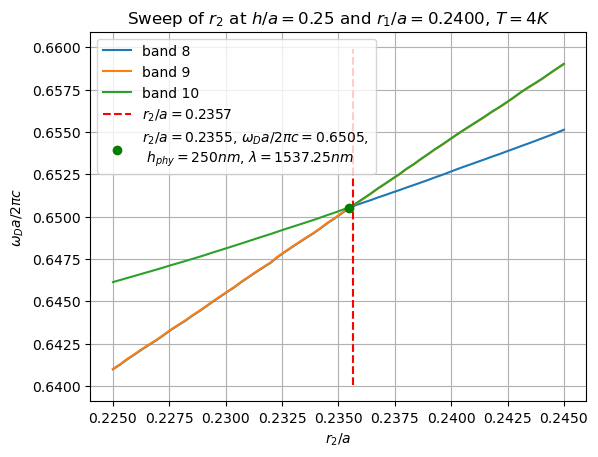

In [13]:
df = sweeper.load_results()
#display(df)
print(r1,r2)
plt.figure()

plt.plot(df["r2"], df["band_8"], label="band 8")
plt.plot(df["r2"], df["band_9"], label="band 9")
plt.plot(df["r2"], df["band_10"], label="band 10")
h_phy = 250

plt.grid()
plt.xlabel("$r_2/a$")
plt.ylabel("$\omega_Da/2\pi c$")
ylim = plt.ylim()
plt.plot([r2, r2], ylim, "r--", label = f"$r_2/a = {r2:0.4f}$")
idx_freq_dirac = np.argmin(np.abs(df["band_10"] - df["band_8"]))
lamX = h_phy / hh / df["band_9"][idx_freq_dirac]
plt.plot(df["r2"][idx_freq_dirac], df["band_8"][idx_freq_dirac], "go", label = f"$r_2/a ={df['r2'][idx_freq_dirac]:0.4f}$, $\omega_Da/2\pi c = {df['band_8'][idx_freq_dirac]:0.4f}$, \n $h_{{phy}} =  {h_phy} nm$, $\lambda = {lamX:0.2f} nm$") 
plt.title(f"Sweep of $r_2$ at $h/a = {hh}$ and $r_1/a = {r1:0.4f}$, $T={T}K$")
plt.legend()
plt.savefig(f"sweep_r2_h_0.35_r1_{r1:0.4f}.png")
plt.show()

c0 = 299792458


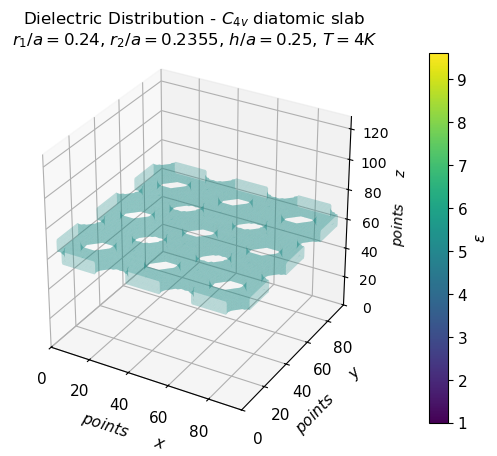

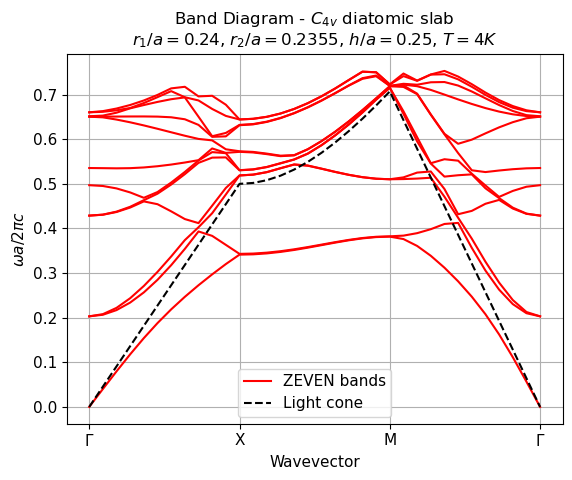

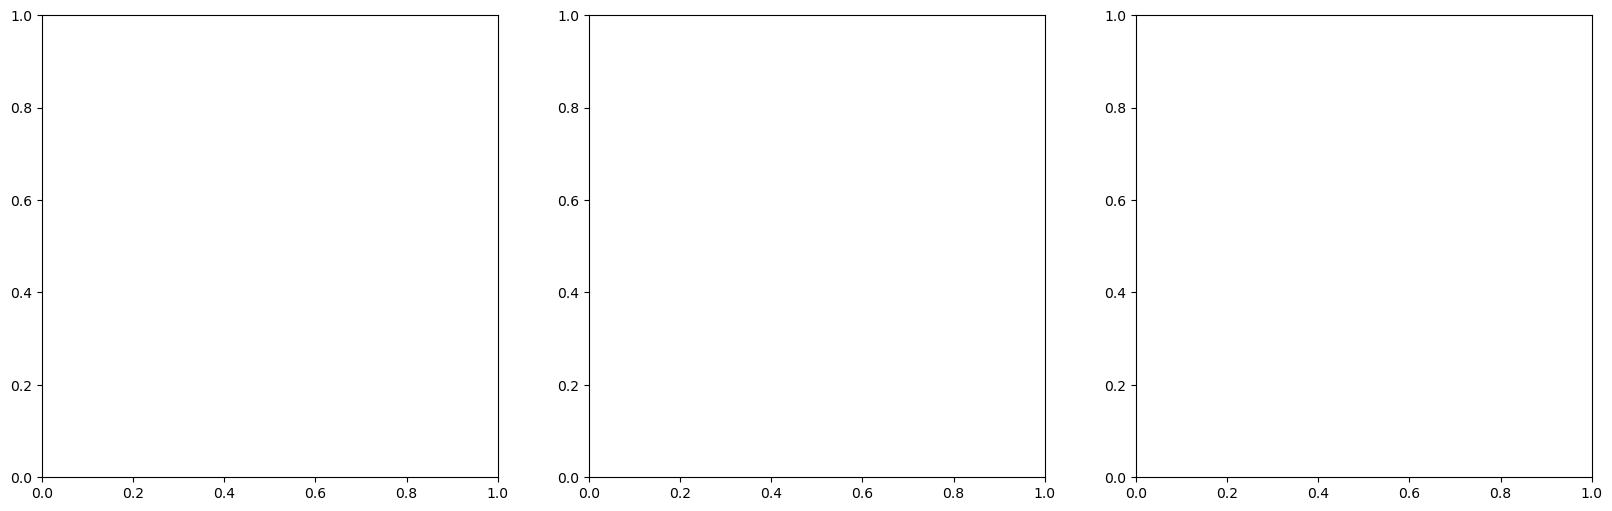

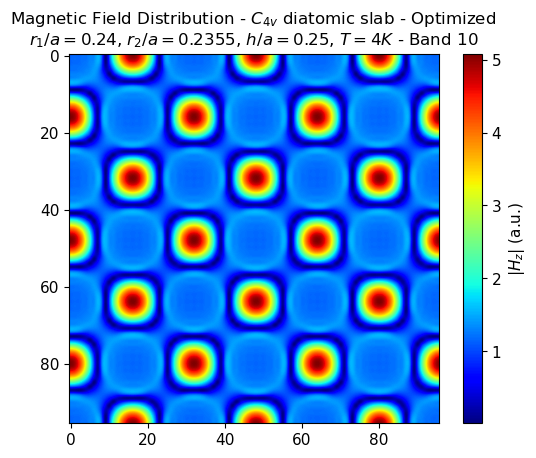

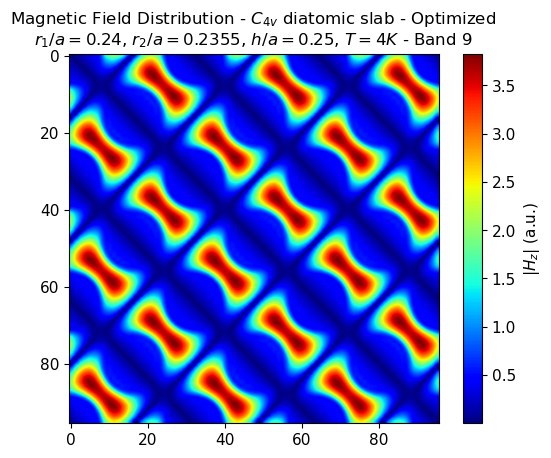

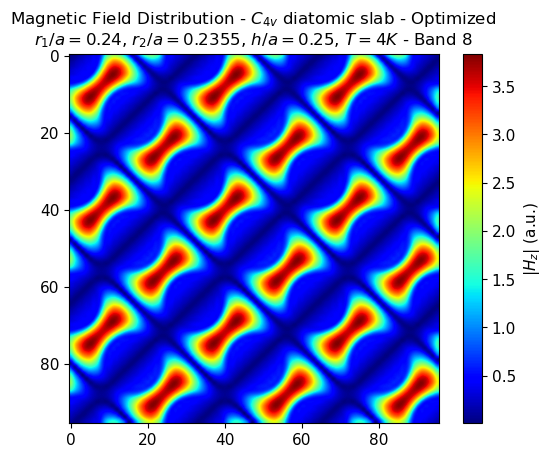

In [23]:

#lsf_config = LSFJobConfiguration(num_processors=4, span_option="hosts", span_value=1, queue="fotonano")
# import time
# time.sleep(1)
r1 = 0.24
r2 = 0.2355
#simulation_slab.run_hpc(mpb_command_line_params=dict(r1 = r1, r2 = r2, h=hh))
viewer_slab = SimulationViewer(simulation_slab) 
opt = MPBDataOptions(rectify=True, periods=(3,3,1))
viewer_slab.figure()
viewer_slab.plot_epsilon_3d(conversion_options=opt)
plt.title(f"Dielectric Distribution - $C_{{4v}}$ diatomic slab \n$r_1/a ={r1}$, $r_2/a = {r2}$, $h/a = {hh}$, $T={T}K$")
plt.xlabel("$points \qquad x$")
plt.ylabel("$points \qquad y$")
ax = plt.gca()
ax.set_zlabel("$points \qquad z$")
viewer_slab.show()
viewer_slab.simulation.extract_frequencies()
viewer_slab.plot_band_diagram("zeven", k_points_path=k_points, color = "red")
#viewer_2D.plot_band_diagram("tm", k_points_path=k_points, color = "blue")
plt.title(f"Band Diagram - $C_{{4v}}$ diatomic slab \n$r_1/a ={r1}$, $r_2/a = {r2}$, $h/a = {hh}$, $T={T}K$")
plt.ylabel("$\omega a/2\pi c$")
df = simulation_slab.load_frequency_data("zeven")
viewer_slab.plot_light_cone(df)
viewer_slab.show()
figure, axes = plt.subplots(1, 3, figsize=(20, 6))

data_line_slab = f"$r_1/a ={r1}$, $r_2/a = {r2}$, $h/a = {hh}$, $T={T}K$"
plt.figure()
c = viewer_slab.plot_field_2d(1, 10, "h", "z", "zeven", False, np.abs) 
plt.title("Magnetic Field Distribution - $C_{4v}$ diatomic slab - Optimized \n" + data_line_slab + " - Band 10")
c.set_label("$|H_{z}|$ (a.u.)")
plt.figure()
c = viewer_slab.plot_field_2d(1, 9, "h", "z", "zeven", False, np.abs)
plt.title("Magnetic Field Distribution - $C_{4v}$ diatomic slab - Optimized \n" + data_line_slab + " - Band 9")
c.set_label("$|H_{z}|$ (a.u.)") 
plt.figure()
c = viewer_slab.plot_field_2d(1, 8, "h", "z", "zeven", False, np.abs)
plt.title("Magnetic Field Distribution - $C_{4v}$ diatomic slab - Optimized \n" + data_line_slab+ " - Band 8")
c.set_label("$|H_{z}|$ (a.u.)")
plt.show()






938.6800000000001

In [ ]:
a1=947.296e-9
f1 = 193.49e12
c0 = 299792458
f2 = c0/1550e-9
print(f1, f2)
a2 = a1 * f1/f2
print(a2)
r_2_D1= 2.2059e-7/a1
print(r_2_D1)
f_mpb_1 = f1*a1/c0
f_mpb_2 = f2*a2/c0
print(f_mpb_1, f_mpb_2)


193490000000000.0 193414489032258.06
9.47665833915008e-07
0.23286280106745938
0.6113973122032309 0.6113973122032309


In [ ]:
938.61*193.41/195.19

930.050515395256

In [ ]:
220.59*f1/f2

222.61497737544818